# CST wake-potential fit: TD-VF versus resonators

This notebook fits the same truncated CST wake-potential data with Time-Domain Vector Fitting and the original IDEFIX resonator model. Both reconstructions are evaluated over the complete available time interval.

TD-VF treats the normalized Gaussian bunch profile as input and the CST wake potential as output. Therefore the RMS bunch duration `SIGMA_T` and the bunch center must match the CST simulation. If CST specifies a spatial bunch length, use `SIGMA_T = SIGMA_Z / scipy.constants.c`.

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import c as c_light

import iddefix
from iddefix.timeDomainVectorFitting import (
    evaluate_frequency_response,
    evaluate_partially_decayed_frequency_response,
    recursive_exponential_convolution,
    sampled_time_derivative,
    time_domain_vector_fit,
)

## User configuration

`TRUNCATION_TIME` is expressed on the physical CST time axis, not on the shifted numerical axis. The resonator bounds are repeated for every resonator; replace them with individual bounds if prior information is available. The wake column must contain one real scalar wake potential.

In [2]:
# CST file and column convention
DATA_FILE = Path('examples/data/004_SPS_model_transitions_q26.txt')
TIME_COLUMN = 0
WAKE_COLUMN = 2
TIME_SCALE_TO_SECONDS = 1.0e-9
DELIMITER = '\t'

# Physical model
PLANE = 'transverse'  # 'longitudinal' or 'transverse'
SIGMA_T = 1.0e-10     # RMS bunch duration [s]
BUNCH_CENTER_TIME = 0.0  # CST normally centers the bunch at t=0
TRUNCATION_TIME = 17e-9  # physical CST time [s], or None for all data




## Load and prepare the CST wake potential

The time axis is reconstructed from its mean spacing to avoid failures caused by decimal round-off in text exports. No resampling of the wake values is performed.

In [3]:
data_candidates = [
    DATA_FILE,
    Path.cwd() / DATA_FILE,
    Path.cwd().parent / DATA_FILE,
]
data_path = next((path.resolve() for path in data_candidates if path.exists()), None)
if data_path is None:
    searched = '\n'.join(str(path.resolve()) for path in data_candidates)
    raise FileNotFoundError(f'CST data file not found. Searched:\n{searched}')
data = np.loadtxt(data_path, comments='#', delimiter=DELIMITER)

physical_times_raw = data[:, TIME_COLUMN] * TIME_SCALE_TO_SECONDS
wake_potential = data[:, WAKE_COLUMN].astype(float)
dt = (physical_times_raw[-1] - physical_times_raw[0]) / (len(physical_times_raw) - 1)
physical_times = physical_times_raw[0] + np.arange(len(physical_times_raw)) * dt
times = physical_times - physical_times[0]

if SIGMA_T <= 0.0:
    raise ValueError('SIGMA_T must be positive.')
if PLANE not in {'longitudinal', 'transverse'}:
    raise ValueError("PLANE must be 'longitudinal' or 'transverse'.")

bunch_profile = np.exp(
    -0.5 * ((physical_times - BUNCH_CENTER_TIME) / SIGMA_T) ** 2
) / (np.sqrt(2.0 * np.pi) * SIGMA_T)

if TRUNCATION_TIME is None:
    fit_mask = np.ones(times.size, dtype=bool)
else:
    fit_mask = physical_times <= TRUNCATION_TIME

if np.count_nonzero(fit_mask) < 3:
    raise ValueError('The selected fit interval contains fewer than three samples.')
if not np.any(fit_mask & (np.abs(physical_times - BUNCH_CENTER_TIME) <= 4.0 * SIGMA_T)):
    raise ValueError('The fit interval does not contain the Gaussian excitation.')

fit_times = times[fit_mask]
fit_physical_times = physical_times[fit_mask]
fit_bunch_profile = bunch_profile[fit_mask]
fit_wake_potential = wake_potential[fit_mask]

print(f'Data file: {data_path}')
print(f'Samples: {times.size}; fit samples: {fit_times.size}')
print(f'dt = {dt:.6e} s')
print(f'sigma_t = {SIGMA_T:.6e} s; sigma_z = {SIGMA_T * c_light:.6e} m')
print(f'Fit ends at physical CST time {fit_physical_times[-1]:.6e} s')

Data file: /home/hschreib/Documents/Iddefix/IDDEFIX/examples/data/004_SPS_model_transitions_q26.txt
Samples: 25636; fit samples: 25636
dt = 6.666667e-13 s
sigma_t = 1.000000e-10 s; sigma_z = 2.997925e-02 m
Fit ends at physical CST time 1.666333e-08 s


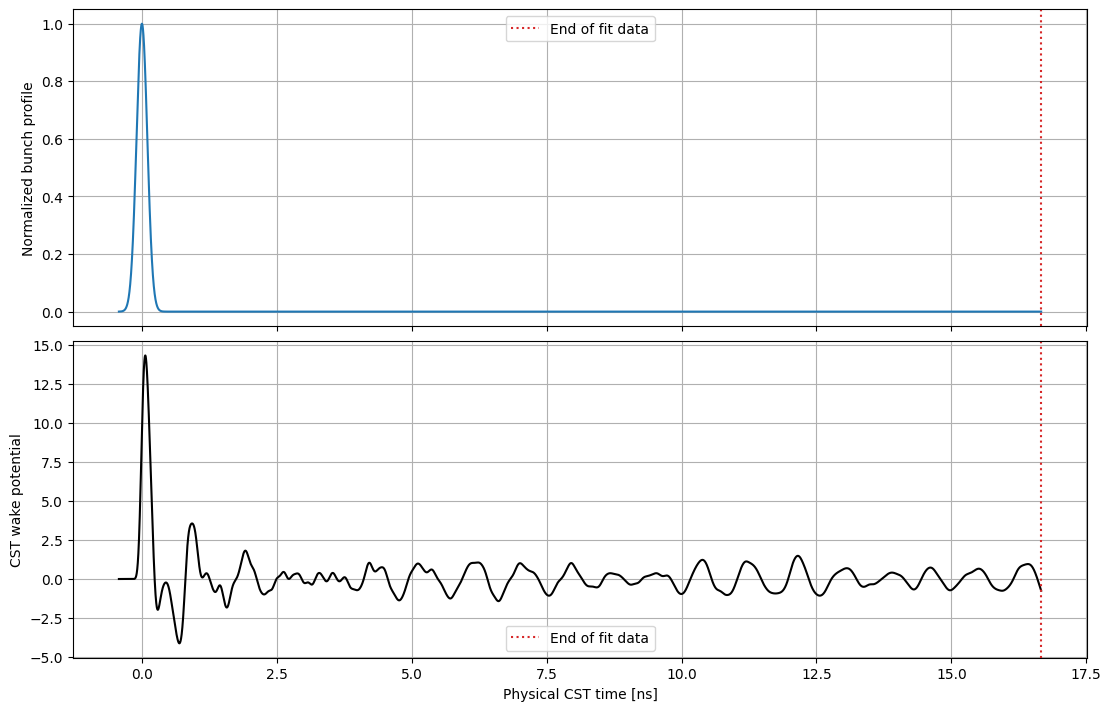

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, constrained_layout=True)
axes[0].plot(physical_times * 1e9, bunch_profile / np.max(bunch_profile), color='tab:blue')
axes[0].set_ylabel('Normalized bunch profile')
axes[1].plot(physical_times * 1e9, wake_potential, color='black')
axes[1].set_ylabel('CST wake potential')
axes[1].set_xlabel('Physical CST time [ns]')
for axis in axes:
    axis.axvline(fit_physical_times[-1] * 1e9, color='tab:red', linestyle=':', label='End of fit data')
    axis.grid(True)
    axis.legend()
plt.show()

Text(0.5, 0, 'frequency [GHz]')

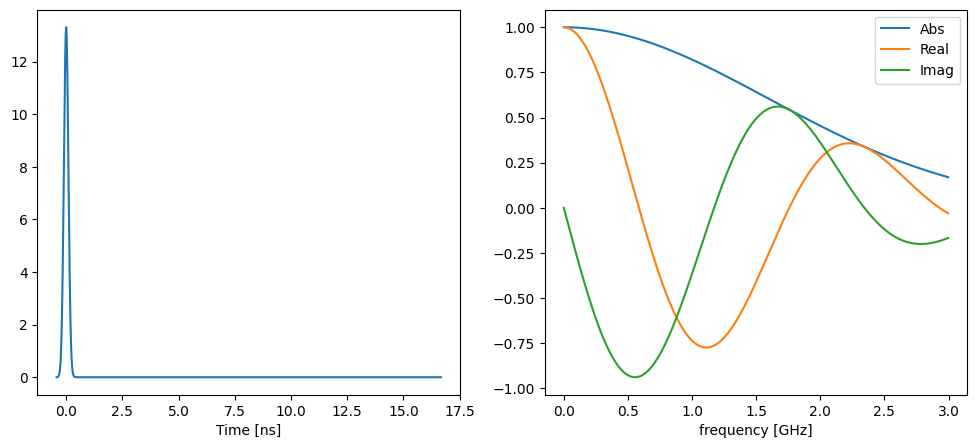

In [5]:
# Function that will be deconvolved under the hood!
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sigma = SIGMA_T
data_time = fit_physical_times
lambdas = (
    1
    / (sigma * np.sqrt(2 * np.pi))
    * np.exp(-(data_time**2) / (2 * sigma**2))
    / c_light
)

axs[0].plot(data_time * 1e9, lambdas, label="charge distribution")
axs[0].set_xlabel("Time [ns]")

ff, lambadf = iddefix.compute_fft(data_time, lambdas)
axs[1].plot(ff / 1e9, np.abs(lambadf), label="Abs")
axs[1].plot(ff / 1e9, np.real(lambadf), label="Real")
axs[1].plot(ff / 1e9, np.imag(lambadf), label="Imag")
axs[1].legend()
axs[1].set_xlabel("frequency [GHz]")

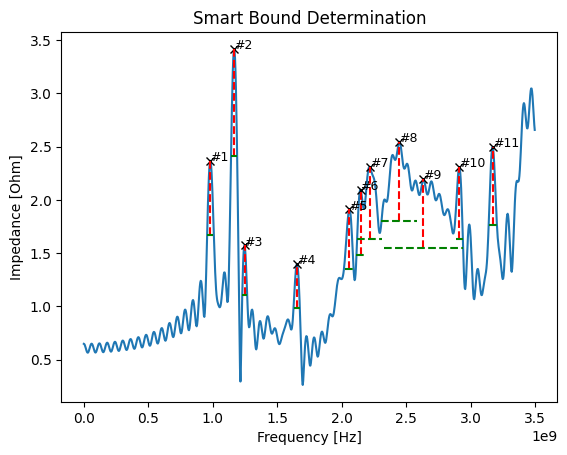

In [29]:
f, Z = iddefix.compute_deconvolution(
    fit_physical_times, fit_wake_potential, sigma=SIGMA_T, fmax=3.5e9
)

heights = np.zeros_like(Z)
heights[f < 1.5e9] = 1.5
heights[f >= 1.5e9] = 1.0
heights[f >= 1.8e9] = 1.5
heights[f >= 2.3e9] = 2.5
heights[f >= 2.6e9] = 2.18
heights[f >= 2.7e9] = 2.3
heights[f >= 3.0e9] = 2.4
heights[f >= 3.2e9] = 100
bounds = iddefix.SmartBoundDetermination(f, np.abs(Z), minimum_peak_height=heights)
bounds.inspect()

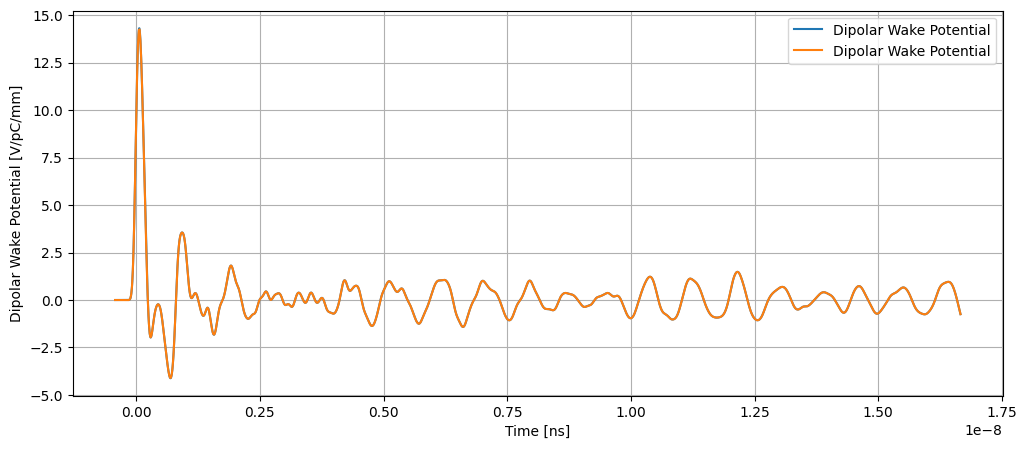

In [7]:
# Decimate wake data
x = np.linspace(fit_physical_times[0], fit_physical_times[-1], 1000)
y = np.interp(x, fit_physical_times, fit_wake_potential)

# Create subplots
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

# Plot data_wake_time vs data_wake_dipolar on the left
ax.plot(fit_physical_times, fit_wake_potential, label="Dipolar Wake Potential")
ax.plot(x, y, label="Dipolar Wake Potential")
ax.set_xlabel("Time [ns]")
ax.set_ylabel("Dipolar Wake Potential [V/pC/mm]")
ax.grid(True)
ax.legend()

data_wake_time = x
data_wake_dipolar = y

In [15]:
%%time
DE_model = iddefix.EvolutionaryAlgorithm(
    data_wake_time,
    data_wake_dipolar * c_light,  # remove normalization
    N_resonators=bounds.N_resonators,
    parameterBounds=bounds.parameterBounds,
    plane="transverse",
    fitFunction="wake potential",
    sigma=sigma,
    objectiveFunction=iddefix.ObjectiveFunctions.sumOfSquaredErrorReal,
)

DE_model.run_differential_evolution(
    maxiter=2000, popsize=180, tol=0.001, mutation=(0.1, 0.5), crossover_rate=0.8
)
print(DE_model.warning)

Differential Evolution:  18%|█▊        | 367/2000 [09:14<41:05,  1.51s/gen, conv=101.3 %]

[!] Warning: 10 parameter(s) have relative uncertainty >= 0.20 (max 1.04).


----------------------------------------------------------------------------
Resonator |   Rs [Ohm/m or Ohm]    |        Q         |       fres [Hz]        
----------------------------------------------------------------------------
    1     |   1.99e+00 ± 4.9e-01   |  85.98 ± 27.19   |   9.90e+08 ± 1.0e+06   
    2     |   6.85e+00 ± 9.6e-01   |  123.31 ± 22.57  |   1.18e+09 ± 3.6e+05   
    3     |   1.26e+00 ± 5.8e-02   |   17.85 ± 1.51   |   1.26e+09 ± 1.7e+06   
    4     |   1.14e+00 ± 9.5e-02   |   36.54 ± 4.78   |   1.66e+09 ± 1.9e+06   
    5     |   1.54e+00 ± 9.0e-01   | 161.94 ± 127.87  |   2.07e+09 ± 2.5e+06   
    6     |   1.71e+00 ± 1.3e+00   | 168.07 ± 174.76  |   2.16e+09 ± 2.7e+06   
    7     |   1.85e+00 ± 1.9e-01   |  54.10 ± 12.04   |   2.23e+09 ± 2.0e+06   
    8     |   2.04e+00 ± 1.6e-01   |   43.57 ± 6.75   |   2.44e+09 ± 2.2e+06   
    9     |   1.83e+00 ± 6.6e-02   |   4.97 ± 0.3

In [17]:
DE_model.run_minimization_algorithm()

Method for minimization : Nelder-Mead
[!] Warning: 9 parameter(s) have relative uncertainty >= 0.20 (max 1.51).


----------------------------------------------------------------------------
Resonator |   Rs [Ohm/m or Ohm]    |        Q         |       fres [Hz]        
----------------------------------------------------------------------------
    1     |   2.13e+00 ± 3.5e-01   |  77.49 ± 16.58   |   1.01e+09 ± 7.8e+05   
    2     |   7.51e+00 ± 9.0e-01   |  134.79 ± 20.52  |   1.18e+09 ± 3.1e+05   
    3     |   1.16e+00 ± 4.8e-02   |   16.41 ± 1.15   |   1.27e+09 ± 1.6e+06   
    4     |   1.19e+00 ± 9.0e-02   |   40.08 ± 4.77   |   1.66e+09 ± 1.5e+06   
    5     |   1.45e+00 ± 8.6e-01   | 175.77 ± 139.28  |   2.08e+09 ± 2.4e+06   
    6     |   1.64e+00 ± 1.5e+00   | 170.72 ± 257.21  |   2.20e+09 ± 4.5e+06   
    7     |   1.67e+00 ± 1.7e-01   |  52.92 ± 16.13   |   2.25e+09 ± 4.1e+06   
    8     |   1.84e+00 ± 1.3e-01   |   39.95 ± 5.37   |   2.43e+09 ± 2.1e+06   
    9     | 

In [18]:
resonator_wake_potential=DE_model.get_wake_potential(physical_times, sigma=SIGMA_T)


## Time-Domain Vector Fitting

In [67]:
# TD-VF model
NUMBER_OF_REAL_POLES = 10
NUMBER_OF_COMPLEX_PAIRS = int(bounds.N_resonators)
FIT_DIRECT_TERM = True
FIT_PROPORTIONAL_TERM = True
MINIMUM_INITIAL_FREQUENCY = 5.0e7
MAXIMUM_INITIAL_FREQUENCY = 3.5e9
TDVF_MAXIMUM_ITERATIONS = 30
TDVF_TOLERANCE = 1.0e-8

In [68]:
def create_initial_poles():
    poles = []

    if NUMBER_OF_REAL_POLES:
        decay_rates = np.geomspace(
            2.0 * np.pi * MINIMUM_INITIAL_FREQUENCY,
            2.0 * np.pi * MAXIMUM_INITIAL_FREQUENCY,
            NUMBER_OF_REAL_POLES,
        )
        poles.extend(-decay_rates.astype(complex))

    if NUMBER_OF_COMPLEX_PAIRS:
        frequencies = np.geomspace(
            MINIMUM_INITIAL_FREQUENCY,
            MAXIMUM_INITIAL_FREQUENCY,
            NUMBER_OF_COMPLEX_PAIRS,
        )
        for frequency in frequencies:
            omega = 2.0 * np.pi * frequency
            pole = -0.05 * omega + 1j * omega
            poles.extend([pole, np.conj(pole)])

    return np.asarray(poles, dtype=complex)


def evaluate_tdvf_time_model(times, input_signal, result):
    dt = times[1] - times[0]
    output = result.direct_term * input_signal.astype(complex)

    if result.proportional_term != 0.0:
        output += result.proportional_term * sampled_time_derivative(
            input_signal, dt
        )

    for pole, residue in zip(result.poles, result.residues):
        output += residue * recursive_exponential_convolution(
            input_signal, pole, dt
        )

    return output


def normalized_l2(reference, approximation):
    norm = np.linalg.norm(reference)
    return np.linalg.norm(approximation - reference) / norm if norm else np.nan

In [69]:
initial_poles = create_initial_poles()
tdvf_start = time.perf_counter()
tdvf_result = time_domain_vector_fit(
    times=fit_times,
    input_signal=fit_bunch_profile,
    output_signal=fit_wake_potential*c_light,
    initial_poles=initial_poles,
    maximum_iterations=TDVF_MAXIMUM_ITERATIONS,
    tolerance=TDVF_TOLERANCE,
    enforce_stability=True,
    weights=None,
    fit_direct_term=FIT_DIRECT_TERM,
    fit_proportional_term=FIT_PROPORTIONAL_TERM,
)
tdvf_runtime = time.perf_counter() - tdvf_start

tdvf_wake_potential = evaluate_tdvf_time_model(
    times, bunch_profile, tdvf_result
).real

print(f'TD-VF runtime: {tdvf_runtime:.3f} s')
print(f'Relocation iterations: {tdvf_result.iterations}')
print(f'Direct term: {tdvf_result.direct_term:.8e}')
print(f'Proportional term: {tdvf_result.proportional_term:.8e}')

TD-VF runtime: 19.680 s
Relocation iterations: 30
Direct term: -8.85768249e-01+0.00000000e+00j
Proportional term: 7.40669824e-11+0.00000000e+00j


In [70]:
tdvf_result

TimeDomainVectorFitResult(poles=array([-4.33950351e+07+6.21073222e+09j, -4.33950351e+07-6.21073222e+09j,
       -1.36110617e+09+6.97009181e+09j, -1.36110617e+09-6.97009181e+09j,
       -2.08675062e+07+7.35762089e+09j, -2.08675062e+07-7.35762089e+09j,
       -1.17788410e+08+7.83300527e+09j, -1.17788410e+08-7.83300527e+09j,
       -2.01311867e+08+9.14481679e+09j, -2.01311867e+08-9.14481679e+09j,
       -2.82943573e+07+1.04540304e+10j, -2.82943573e+07-1.04540304e+10j,
       -6.83074052e+08+1.18462102e+10j, -6.83074052e+08-1.18462102e+10j,
       -3.19329680e+07+1.30521561e+10j, -3.19329680e+07-1.30521561e+10j,
       -3.24299434e+08+1.42463954e+10j, -3.24299434e+08-1.42463954e+10j,
       -1.37200099e+09+1.49182565e+10j, -1.37200099e+09-1.49182565e+10j,
       -1.50039389e+07+1.83936278e+10j, -1.50039389e+07-1.83936278e+10j,
       -2.04500937e+08+1.96926294e+10j, -2.04500937e+08-1.96926294e+10j,
       -4.31274909e+08+2.04763126e+10j, -4.31274909e+08-2.04763126e+10j,
       -1.28868626e

## Common comparison over fit and extrapolation intervals

Normalized L2 errors
--------------------------------------------------------------------
TD-VF        fit=6.369252e-02  validation=nan  full=6.369252e-02
Resonators   fit=2.815406e-01  validation=nan  full=2.815406e-01


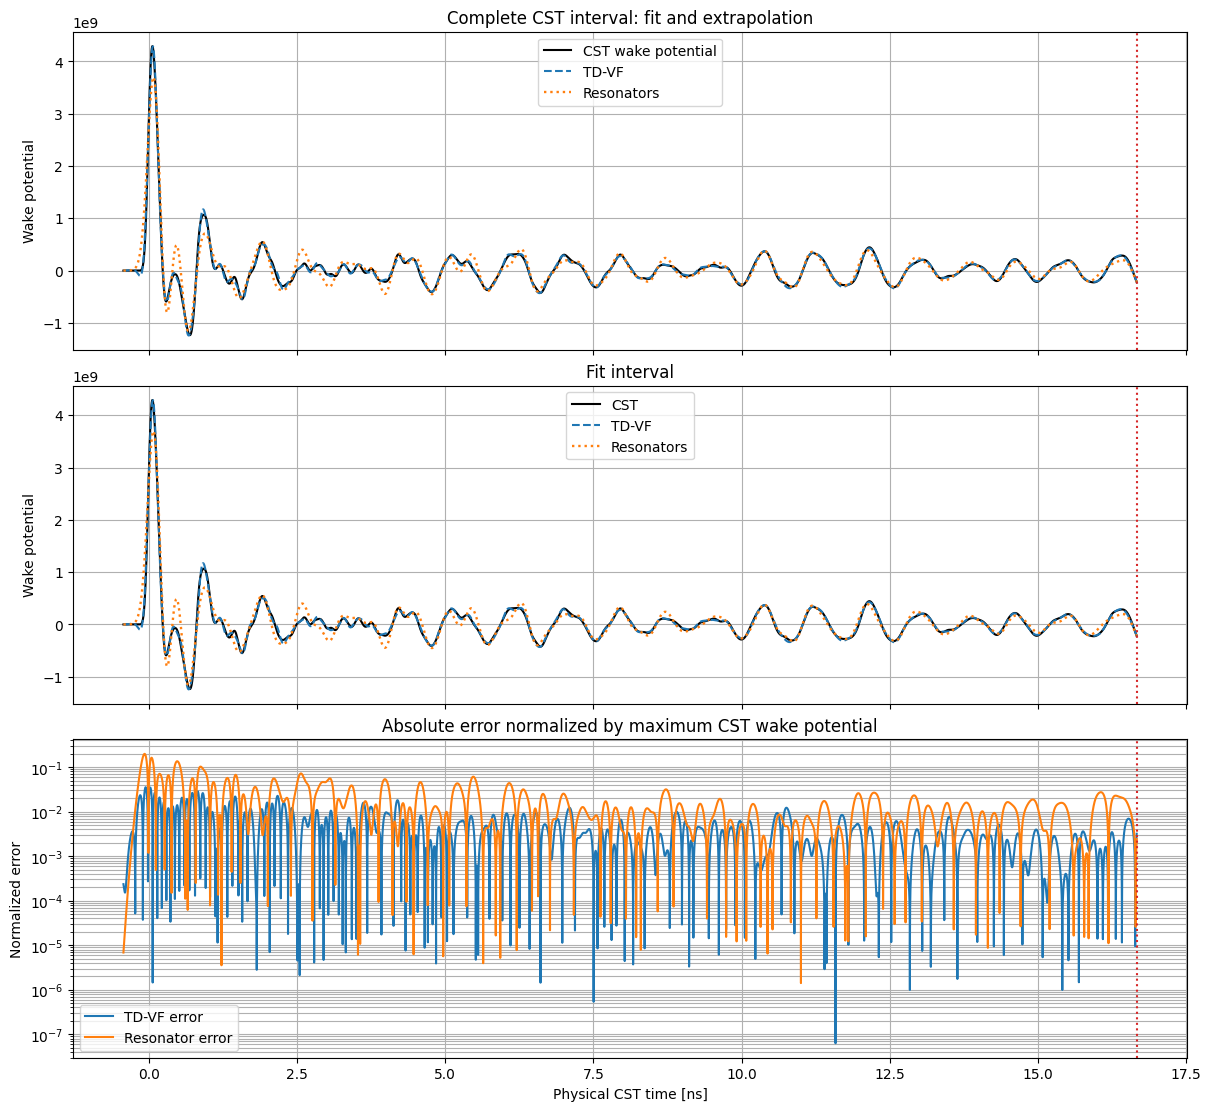

In [71]:
validation_mask = ~fit_mask
models = {
    'TD-VF': tdvf_wake_potential,
    'Resonators': resonator_wake_potential,
}

print('Normalized L2 errors')
print('-' * 68)
for name, model_wake in models.items():
    fit_error = normalized_l2(wake_potential[fit_mask]*c_light, model_wake[fit_mask])
    full_error = normalized_l2(wake_potential*c_light, model_wake)
    validation_error = (
        normalized_l2(wake_potential[validation_mask]*c_light, model_wake[validation_mask])
        if np.any(validation_mask) else np.nan
    )
    print(f'{name:12s} fit={fit_error:.6e}  validation={validation_error:.6e}  full={full_error:.6e}')

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True, constrained_layout=True)
time_ns = physical_times * 1e9
end_ns = fit_physical_times[-1] * 1e9

axes[0].plot(time_ns, wake_potential*c_light, color='black', linewidth=1.5, label='CST wake potential')
axes[0].plot(time_ns, tdvf_wake_potential, '--', label='TD-VF')
axes[0].plot(time_ns, resonator_wake_potential, ':', linewidth=1.7, label='Resonators')
axes[0].set_title('Complete CST interval: fit and extrapolation')
axes[0].set_ylabel('Wake potential')
axes[0].legend()

axes[1].plot(time_ns[fit_mask], wake_potential[fit_mask]*c_light, color='black', linewidth=1.5, label='CST')
axes[1].plot(time_ns[fit_mask], tdvf_wake_potential[fit_mask], '--', label='TD-VF')
axes[1].plot(time_ns[fit_mask], resonator_wake_potential[fit_mask], ':', linewidth=1.7, label='Resonators')
axes[1].set_title('Fit interval')
axes[1].set_ylabel('Wake potential')
axes[1].legend()

scale = max(np.max(np.abs(wake_potential*c_light)), np.finfo(float).eps)
axes[2].semilogy(time_ns, np.maximum(np.abs(tdvf_wake_potential - wake_potential*c_light) / scale, np.finfo(float).eps), label='TD-VF error')
axes[2].semilogy(time_ns, np.maximum(np.abs(resonator_wake_potential - wake_potential*c_light) / scale, np.finfo(float).eps), label='Resonator error')
axes[2].set_title('Absolute error normalized by maximum CST wake potential')
axes[2].set_xlabel('Physical CST time [ns]')
axes[2].set_ylabel('Normalized error')
axes[2].legend()

for axis in axes:
    axis.axvline(end_ns, color='tab:red', linestyle=':', label='End of fit data')
    axis.grid(True, which='both')
plt.show()

In [72]:
# Impedance comparison
MAXIMUM_IMPEDANCE_FREQUENCY = 3.5e9
NUMBER_OF_IMPEDANCE_SAMPLES = 2001

In [73]:
impedance_frequencies, cst_impedance = iddefix.compute_deconvolution(
    physical_times,
    wake_potential,
    sigma=SIGMA_T,
    fmax=MAXIMUM_IMPEDANCE_FREQUENCY,
  #  samples=NUMBER_OF_IMPEDANCE_SAMPLES,
)

tdvf_impedance_fd = evaluate_frequency_response(
    frequencies=impedance_frequencies,
    poles=tdvf_result.poles,
    residues=tdvf_result.residues,
    direct_term=tdvf_result.direct_term,
    fourier_sign=-1,
    proportional_term=tdvf_result.proportional_term,
)

tdvf_impedance_pd = (
    evaluate_partially_decayed_frequency_response(
        frequencies=impedance_frequencies,
        poles=tdvf_result.poles,
        residues=tdvf_result.residues,
        wake_length=physical_times[-1] * c_light,
        direct_term=tdvf_result.direct_term,
        fourier_sign=-1,
        proportional_term=(
            tdvf_result.proportional_term
        ),
    )
)


resonator_impedance_pd = DE_model.get_impedance( frequency_data=impedance_frequencies, wakelength=physical_times[-1] * c_light)

resonator_impedance_fd = DE_model.get_impedance( frequency_data=impedance_frequencies, wakelength=None)

if PLANE == 'transverse':
    convention_factor = 1j
else:
    convention_factor = -1.0

# compute_deconvolution and TD-VF return the raw transform convention.
# get_impedance already returns the IDEFIX longitudinal/transverse convention.
cst_impedance *= convention_factor
tdvf_impedance_fd *= convention_factor
resonator_impedance_fd *= 1.0

tdvf_impedance_pd *= convention_factor
resonator_impedance_pd *= 1.0

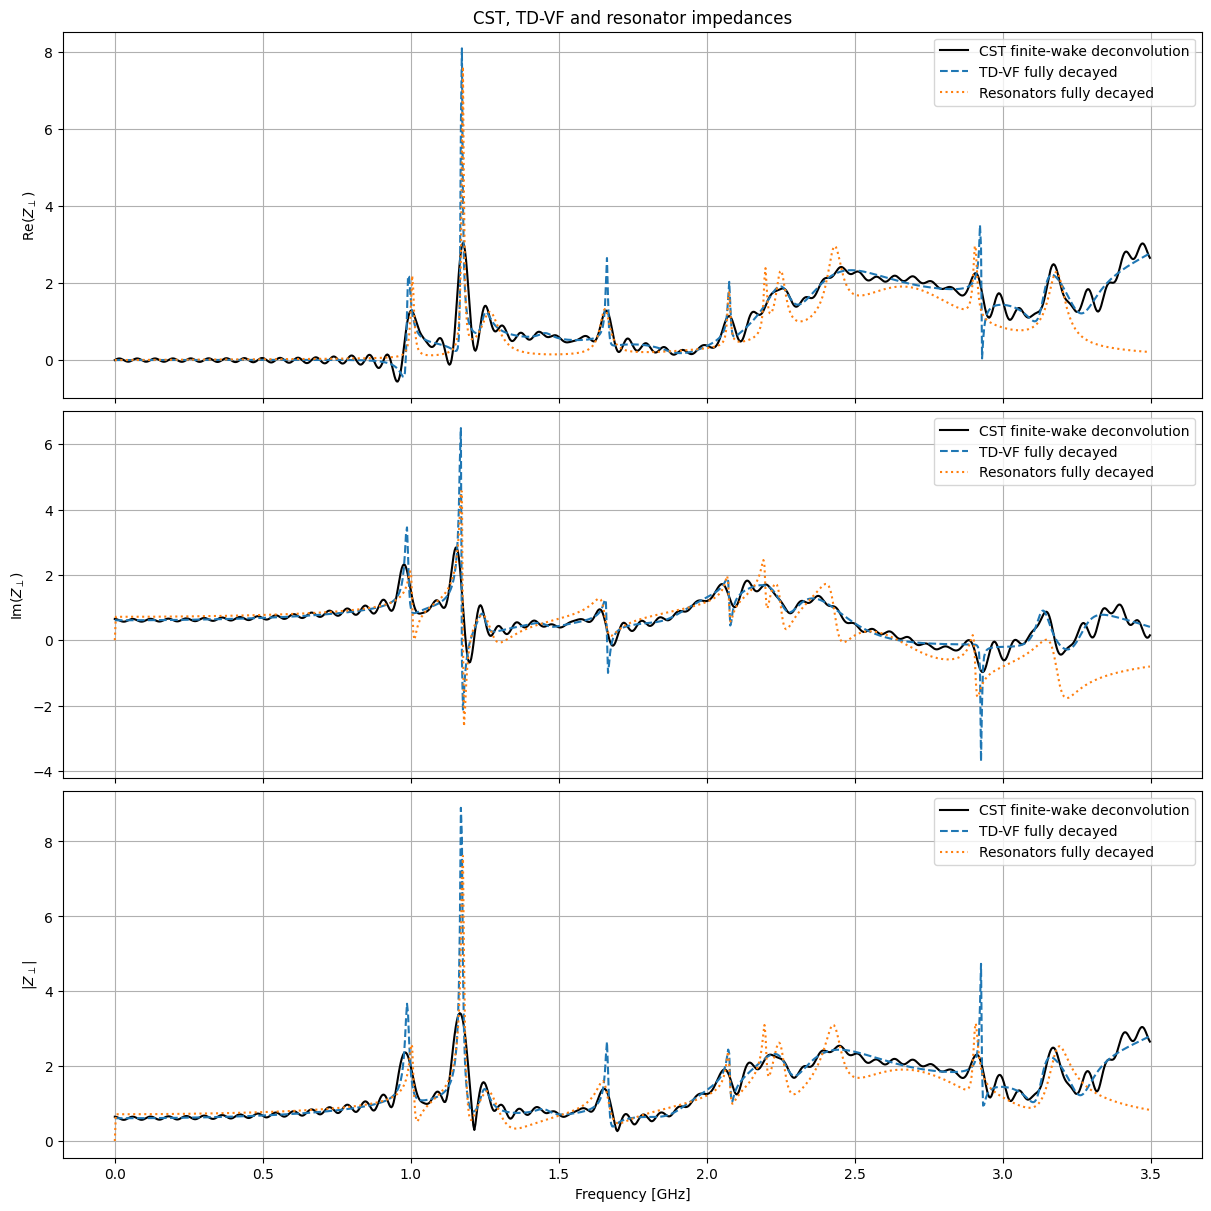

In [74]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True, constrained_layout=True)
curves = {
    'CST finite-wake deconvolution': (cst_impedance, 'black', '-'),
    'TD-VF fully decayed': (tdvf_impedance_fd, 'tab:blue', '--'),
    'Resonators fully decayed': (resonator_impedance_fd, 'tab:orange', ':'),
}
frequency_ghz = impedance_frequencies / 1.0e9

for label, (impedance, color, linestyle) in curves.items():
    axes[0].plot(frequency_ghz, impedance.real, color=color, linestyle=linestyle, label=label)
    axes[1].plot(frequency_ghz, impedance.imag, color=color, linestyle=linestyle, label=label)
    axes[2].plot(
        frequency_ghz,
        np.maximum(np.abs(impedance), np.finfo(float).eps),
        color=color,
        linestyle=linestyle,
        label=label,
    )

impedance_symbol = r'Z_\perp' if PLANE == 'transverse' else r'Z_\parallel'
axes[0].set_ylabel(rf'$\operatorname{{Re}}({impedance_symbol})$')
axes[1].set_ylabel(rf'$\operatorname{{Im}}({impedance_symbol})$')
axes[2].set_ylabel(rf'$|{impedance_symbol}|$')
axes[2].set_xlabel('Frequency [GHz]')
axes[0].set_title('CST, TD-VF and resonator impedances')
for axis in axes:
    axis.grid(True, which='both')
    axis.legend()
plt.show()

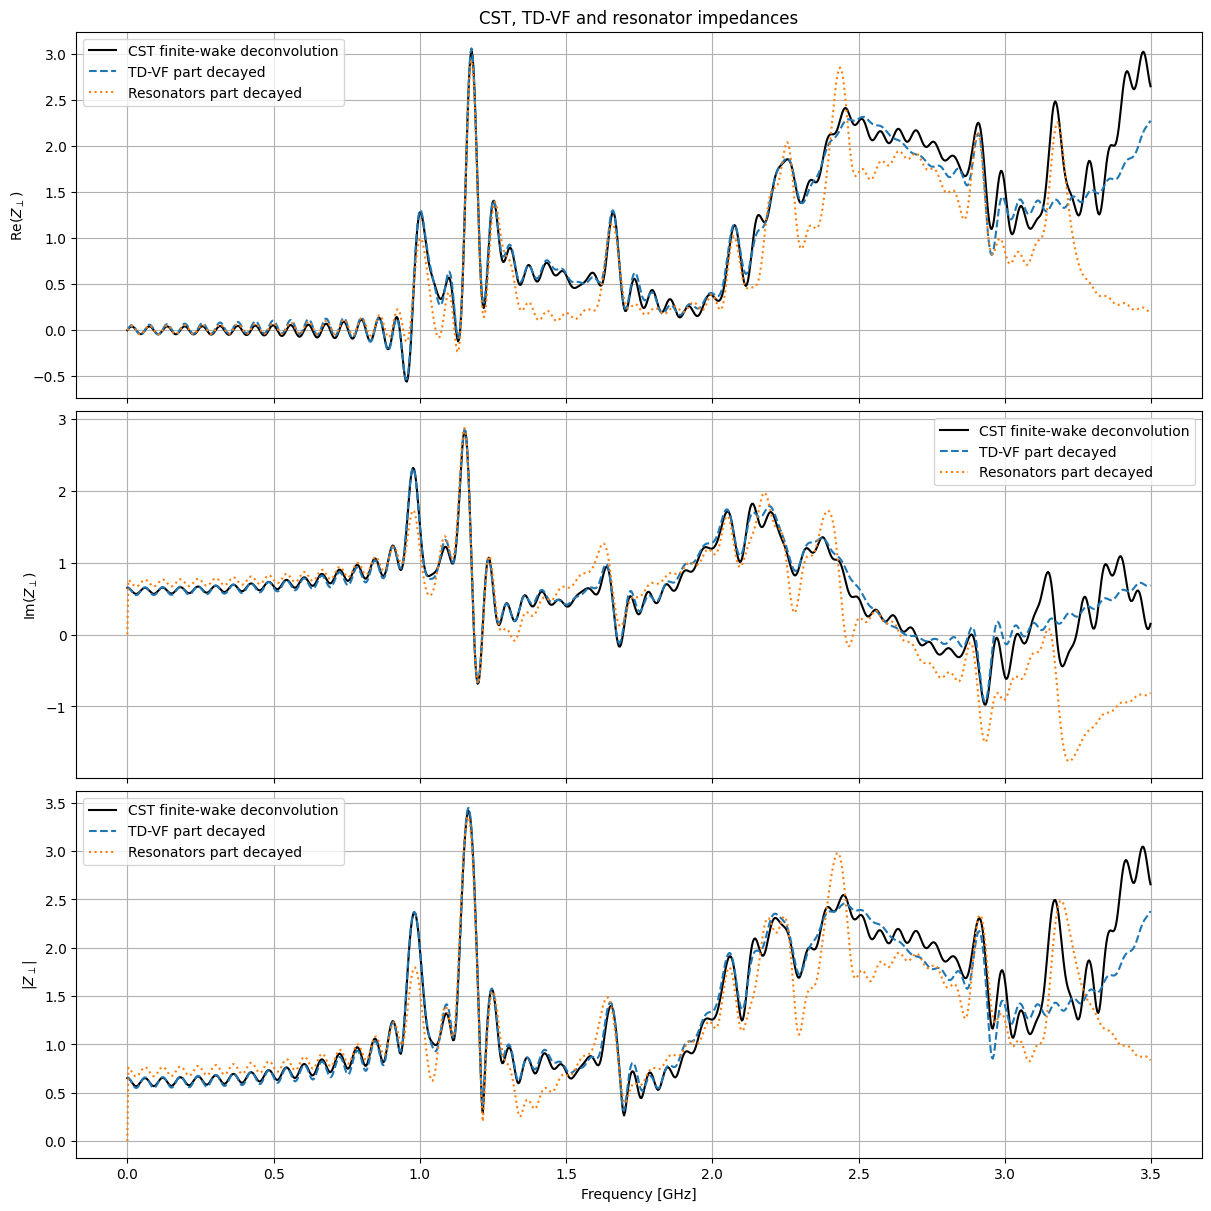

In [56]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True, constrained_layout=True)
curves = {
    'CST finite-wake deconvolution': (cst_impedance, 'black', '-'),
    'TD-VF part decayed': (tdvf_impedance_pd, 'tab:blue', '--'),
    'Resonators part decayed': (resonator_impedance_pd, 'tab:orange', ':'),
}
frequency_ghz = impedance_frequencies / 1.0e9

for label, (impedance, color, linestyle) in curves.items():
    axes[0].plot(frequency_ghz, impedance.real, color=color, linestyle=linestyle, label=label)
    axes[1].plot(frequency_ghz, impedance.imag, color=color, linestyle=linestyle, label=label)
    axes[2].plot(
        frequency_ghz,
        np.maximum(np.abs(impedance), np.finfo(float).eps),
        color=color,
        linestyle=linestyle,
        label=label,
    )

impedance_symbol = r'Z_\perp' if PLANE == 'transverse' else r'Z_\parallel'
axes[0].set_ylabel(rf'$\operatorname{{Re}}({impedance_symbol})$')
axes[1].set_ylabel(rf'$\operatorname{{Im}}({impedance_symbol})$')
axes[2].set_ylabel(rf'$|{impedance_symbol}|$')
axes[2].set_xlabel('Frequency [GHz]')
axes[0].set_title('CST, TD-VF and resonator impedances')
for axis in axes:
    axis.grid(True, which='both')
    axis.legend()
plt.show()

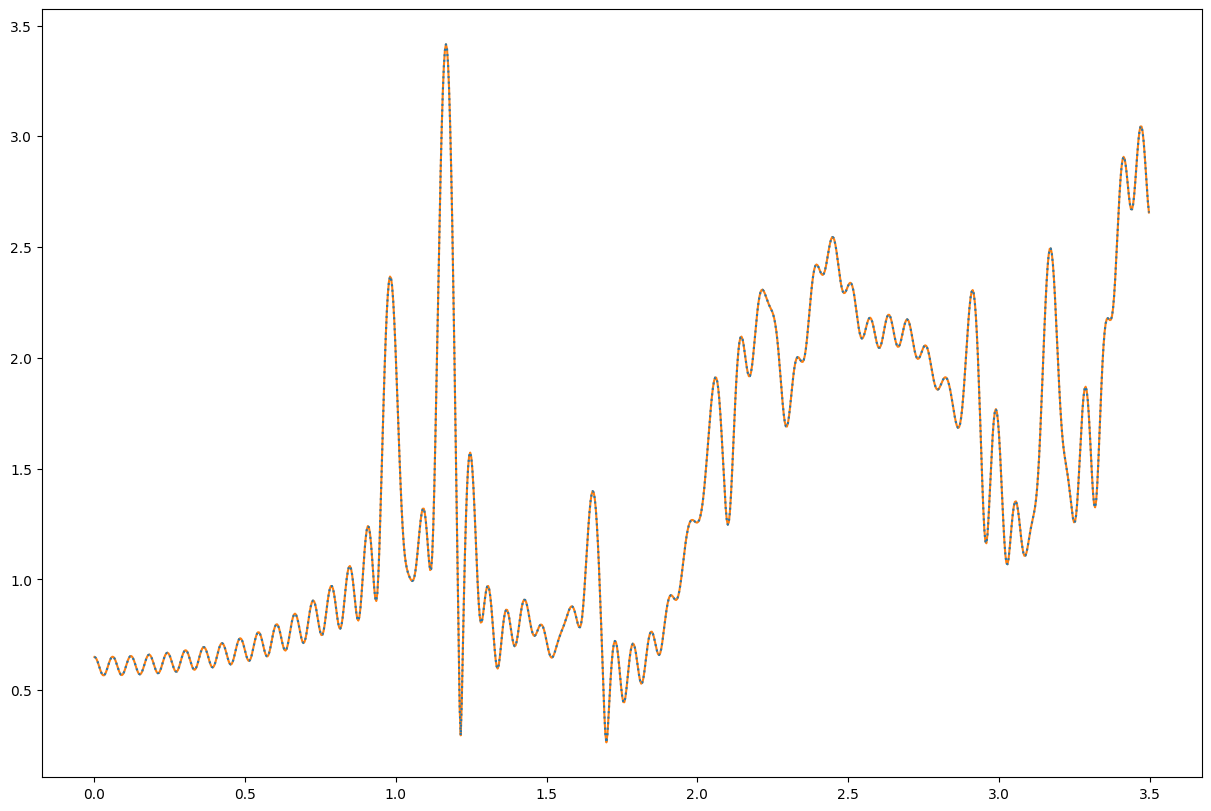

In [39]:
fig, axes = plt.subplots(1, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
axes.plot(frequency_ghz, np.abs(cst_impedance), color=color,  label=label)
axes.plot(f*1e-9, np.abs(Z), color="tab:blue",linestyle=linestyle, label=label)
plt.show()